# Optimal (c_pos, c_neg) per ROI: matching negative-residual median to 0.674 × noise_std

**Question:** Among the 8 binit0 runs differing only in `(c_pos, c_neg)`, which combination produces negative residuals whose median absolute value is closest to `0.674 × noise_std(F, 'mad')`?

**Rationale:** For a zero-mean Gaussian with std σ, the median of |x| for x < 0 equals 0.6745 σ (the half-normal median). So the target `0.674 σ_noise` is what we expect if the negative residuals (fluorescence below the baseline) are pure Gaussian noise — no systematically over-subtracted signal. A run where the negative residuals are too small (close to 0) over-fits; too large means the baseline is too low.

**Then:** Do F metrics (skewness, SNR, bleaching, sustained) predict which `(c_pos, c_neg)` wins?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from tqdm.auto import tqdm

# --- Run definitions ---
RUNS = {
    (2, 3): Path('/scratch/runs/0001_binit0_c23'),
    (2, 4): Path('/scratch/runs/0002_binit0_c24'),
    (2, 5): Path('/scratch/runs/0003_binit0_c25'),
    (3, 3): Path('/scratch/runs/0004_binit0_c33'),
    (3, 4): Path('/scratch/runs/0005_binit0_c34'),
    (3, 5): Path('/scratch/runs/0006_binit0_c35'),
    (4, 4): Path('/scratch/runs/0007_binit0_c44'),
    (4, 5): Path('/scratch/runs/0008_binit0_c45'),
}
COMBOS = sorted(RUNS.keys())

INPUTS_DIR = Path('/scratch/runs/0000_first_try')

TARGET_COEF = 0.674   # half-normal median coefficient

print(f"{len(COMBOS)} combos, runs:")
for c, p in RUNS.items():
    print(f"  c_pos={c[0]}, c_neg={c[1]}  →  {p.name}")

8 combos, runs:
  c_pos=2, c_neg=3  →  0001_binit0_c23
  c_pos=2, c_neg=4  →  0002_binit0_c24
  c_pos=2, c_neg=5  →  0003_binit0_c25
  c_pos=3, c_neg=3  →  0004_binit0_c33
  c_pos=3, c_neg=4  →  0005_binit0_c34
  c_pos=3, c_neg=5  →  0006_binit0_c35
  c_pos=4, c_neg=4  →  0007_binit0_c44
  c_pos=4, c_neg=5  →  0008_binit0_c45


## 1. Compute per-ROI metric across all sessions

In [2]:
def compute_session_metrics(session_key: str) -> pd.DataFrame | None:
    """For every ROI in this session: compute |median(neg resid of F0trend)| for each combo,
    find the best combo, and collect F metrics."""
    inp = INPUTS_DIR / session_key
    if not inp.exists():
        return None

    F     = np.load(inp / 'F_all_array.npy',   mmap_mode='r').astype(np.float32)
    noise = np.load(inp / 'F_noise.npy').astype(np.float64)
    skew  = np.load(inp / 'F_skewness.npy').astype(np.float64)
    snr   = np.load(inp / 'F_snr.npy').astype(np.float64)
    bl    = np.load(inp / 'bleaching_metric.npy').astype(np.float64)
    sus   = np.load(inp / 'sustained_metric.npy').astype(np.float64)
    N     = F.shape[0]

    # Load F0trend arrays (IRLS trend, float64 for precision)
    f0trend_arrays = {}
    for combo, run_dir in RUNS.items():
        p = run_dir / session_key / 'F0trend_all.npy'
        if not p.exists():
            return None
        f0trend_arrays[combo] = np.load(p, mmap_mode='r')

    target = TARGET_COEF * noise   # (N,)

    # Per-combo metric: |median(neg residuals of F - F0trend)|
    med_neg = np.full((N, len(COMBOS)), np.nan)
    for j, combo in enumerate(COMBOS):
        f0 = f0trend_arrays[combo]  # (N, T)
        for i in range(N):
            res = F[i].astype(np.float64) - f0[i]
            valid = ~np.isnan(f0[i])
            neg = res[valid & (res < 0)]
            if len(neg) > 10:
                med_neg[i, j] = np.median(np.abs(neg))

    # Distance from target
    dist = np.abs(med_neg - target[:, None])   # (N, 8)

    best_idx    = np.argmin(dist, axis=1)       # (N,)
    best_combo  = [COMBOS[k] for k in best_idx]
    best_cpos   = np.array([c[0] for c in best_combo])
    best_cneg   = np.array([c[1] for c in best_combo])
    best_dist   = dist[np.arange(N), best_idx]
    best_med    = med_neg[np.arange(N), best_idx]

    df = pd.DataFrame({
        'session':      session_key,
        'roi_idx':      np.arange(N),
        'noise':        noise,
        'target':       target,
        'skewness':     skew,
        'snr':          snr,
        'bleaching':    bl,
        'sustained':    sus,
        'best_cpos':    best_cpos,
        'best_cneg':    best_cneg,
        'best_dist':    best_dist,
        'best_med_neg': best_med,
        'ratio':        best_med / np.where(target > 0, target, np.nan),
    })
    # Store per-combo medians
    for j, combo in enumerate(COMBOS):
        df[f'med_neg_{combo[0]}_{combo[1]}'] = med_neg[:, j]
    return df


# Collect all sessions from run 0001 (representative)
all_sessions = sorted(
    p.name for p in RUNS[(2,3)].iterdir()
    if p.is_dir() and (p / 'F0trend_all.npy').exists()
)
print(f"Total sessions: {len(all_sessions)}")

frames = []
for sess in tqdm(all_sessions):
    df = compute_session_metrics(sess)
    if df is not None:
        frames.append(df)

data = pd.concat(frames, ignore_index=True)
data['subject'] = data['session'].str.split('_').str[0]
data['combo_label'] = data.apply(lambda r: f"({int(r.best_cpos)},{int(r.best_cneg)})", axis=1)
print(f"\nTotal ROIs: {len(data):,}")
print(data['combo_label'].value_counts().sort_index())

Total sessions: 42


  0%|          | 0/42 [00:00<?, ?it/s]


Total ROIs: 20,501
combo_label
(2,3)    7276
(2,4)    3373
(2,5)    4670
(3,3)      32
(3,4)    1307
(3,5)    3687
(4,5)     156
Name: count, dtype: int64


## 2. Which (c_pos, c_neg) wins, and how cleanly?

/tmp/ipykernel_40789/2301316897.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(COMBO_LABELS, rotation=45, ha='right')


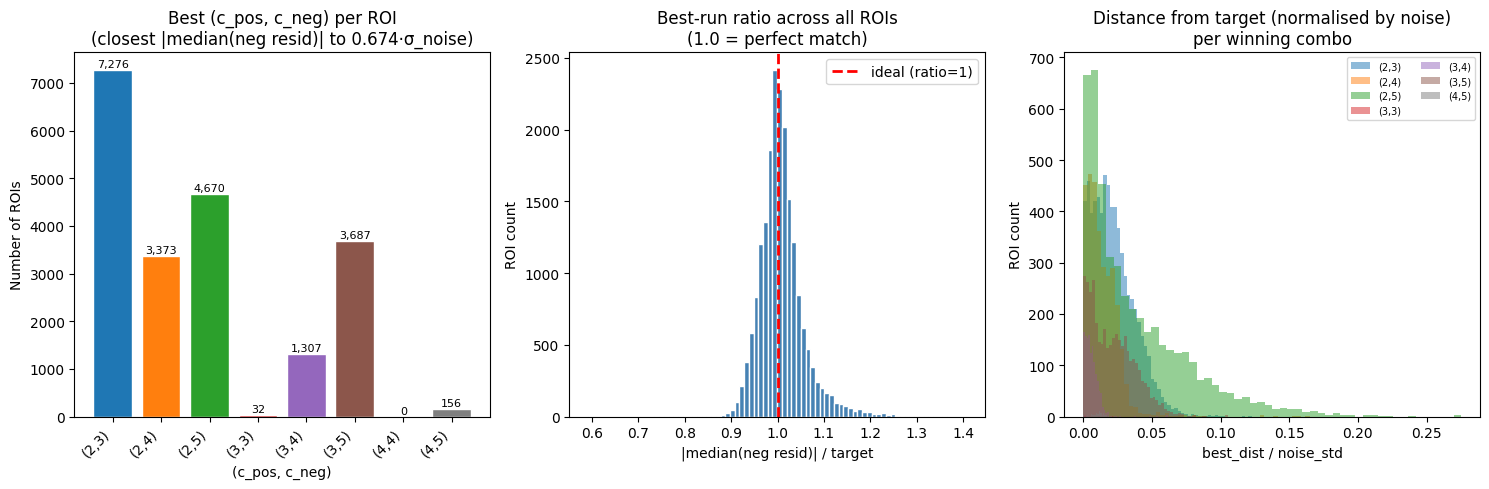

In [3]:
COMBO_LABELS = [f"({c[0]},{c[1]})" for c in COMBOS]
counts = data['combo_label'].value_counts().reindex(COMBO_LABELS, fill_value=0)

cmap8 = plt.get_cmap('tab10')
COLORS = {lbl: cmap8(i) for i, lbl in enumerate(COMBO_LABELS)}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Count bar chart ---
ax = axes[0]
bars = ax.bar(COMBO_LABELS, counts.values,
              color=[COLORS[l] for l in COMBO_LABELS], edgecolor='white')
ax.set_xlabel('(c_pos, c_neg)')
ax.set_ylabel('Number of ROIs')
ax.set_title('Best (c_pos, c_neg) per ROI\n(closest |median(neg resid)| to 0.674·σ_noise)')
ax.set_xticklabels(COMBO_LABELS, rotation=45, ha='right')
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{v:,}', ha='center', va='bottom', fontsize=8)

# --- Ratio distribution (best_med / target) ---
ax = axes[1]
ax.hist(data['ratio'].clip(0, 3), bins=80, color='steelblue', edgecolor='white')
ax.axvline(1.0, color='red', lw=2, ls='--', label='ideal (ratio=1)')
ax.set_xlabel('|median(neg resid)| / target')
ax.set_ylabel('ROI count')
ax.set_title('Best-run ratio across all ROIs\n(1.0 = perfect match)')
ax.legend()

# --- Distance distribution ---
ax = axes[2]
for lbl in COMBO_LABELS:
    subset = data[data['combo_label'] == lbl]
    if len(subset) > 0:
        ax.hist(subset['best_dist'] / subset['noise'],
                bins=50, alpha=0.5, label=lbl, color=COLORS[lbl])
ax.set_xlabel('best_dist / noise_std')
ax.set_ylabel('ROI count')
ax.set_title('Distance from target (normalised by noise)\nper winning combo')
ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig('/root/capsule/code/04_fig1_combo_counts.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. F metric distributions by winning combo

/tmp/ipykernel_40789/2617810542.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(vals_by_combo, labels=labels_plot, patch_artist=True,
/tmp/ipykernel_40789/2617810542.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(vals_by_combo, labels=labels_plot, patch_artist=True,
/tmp/ipykernel_40789/2617810542.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(vals_by_combo, labels=labels_plot, patch_artist=True,
/tmp/ipykernel_40789/2617810542.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; su

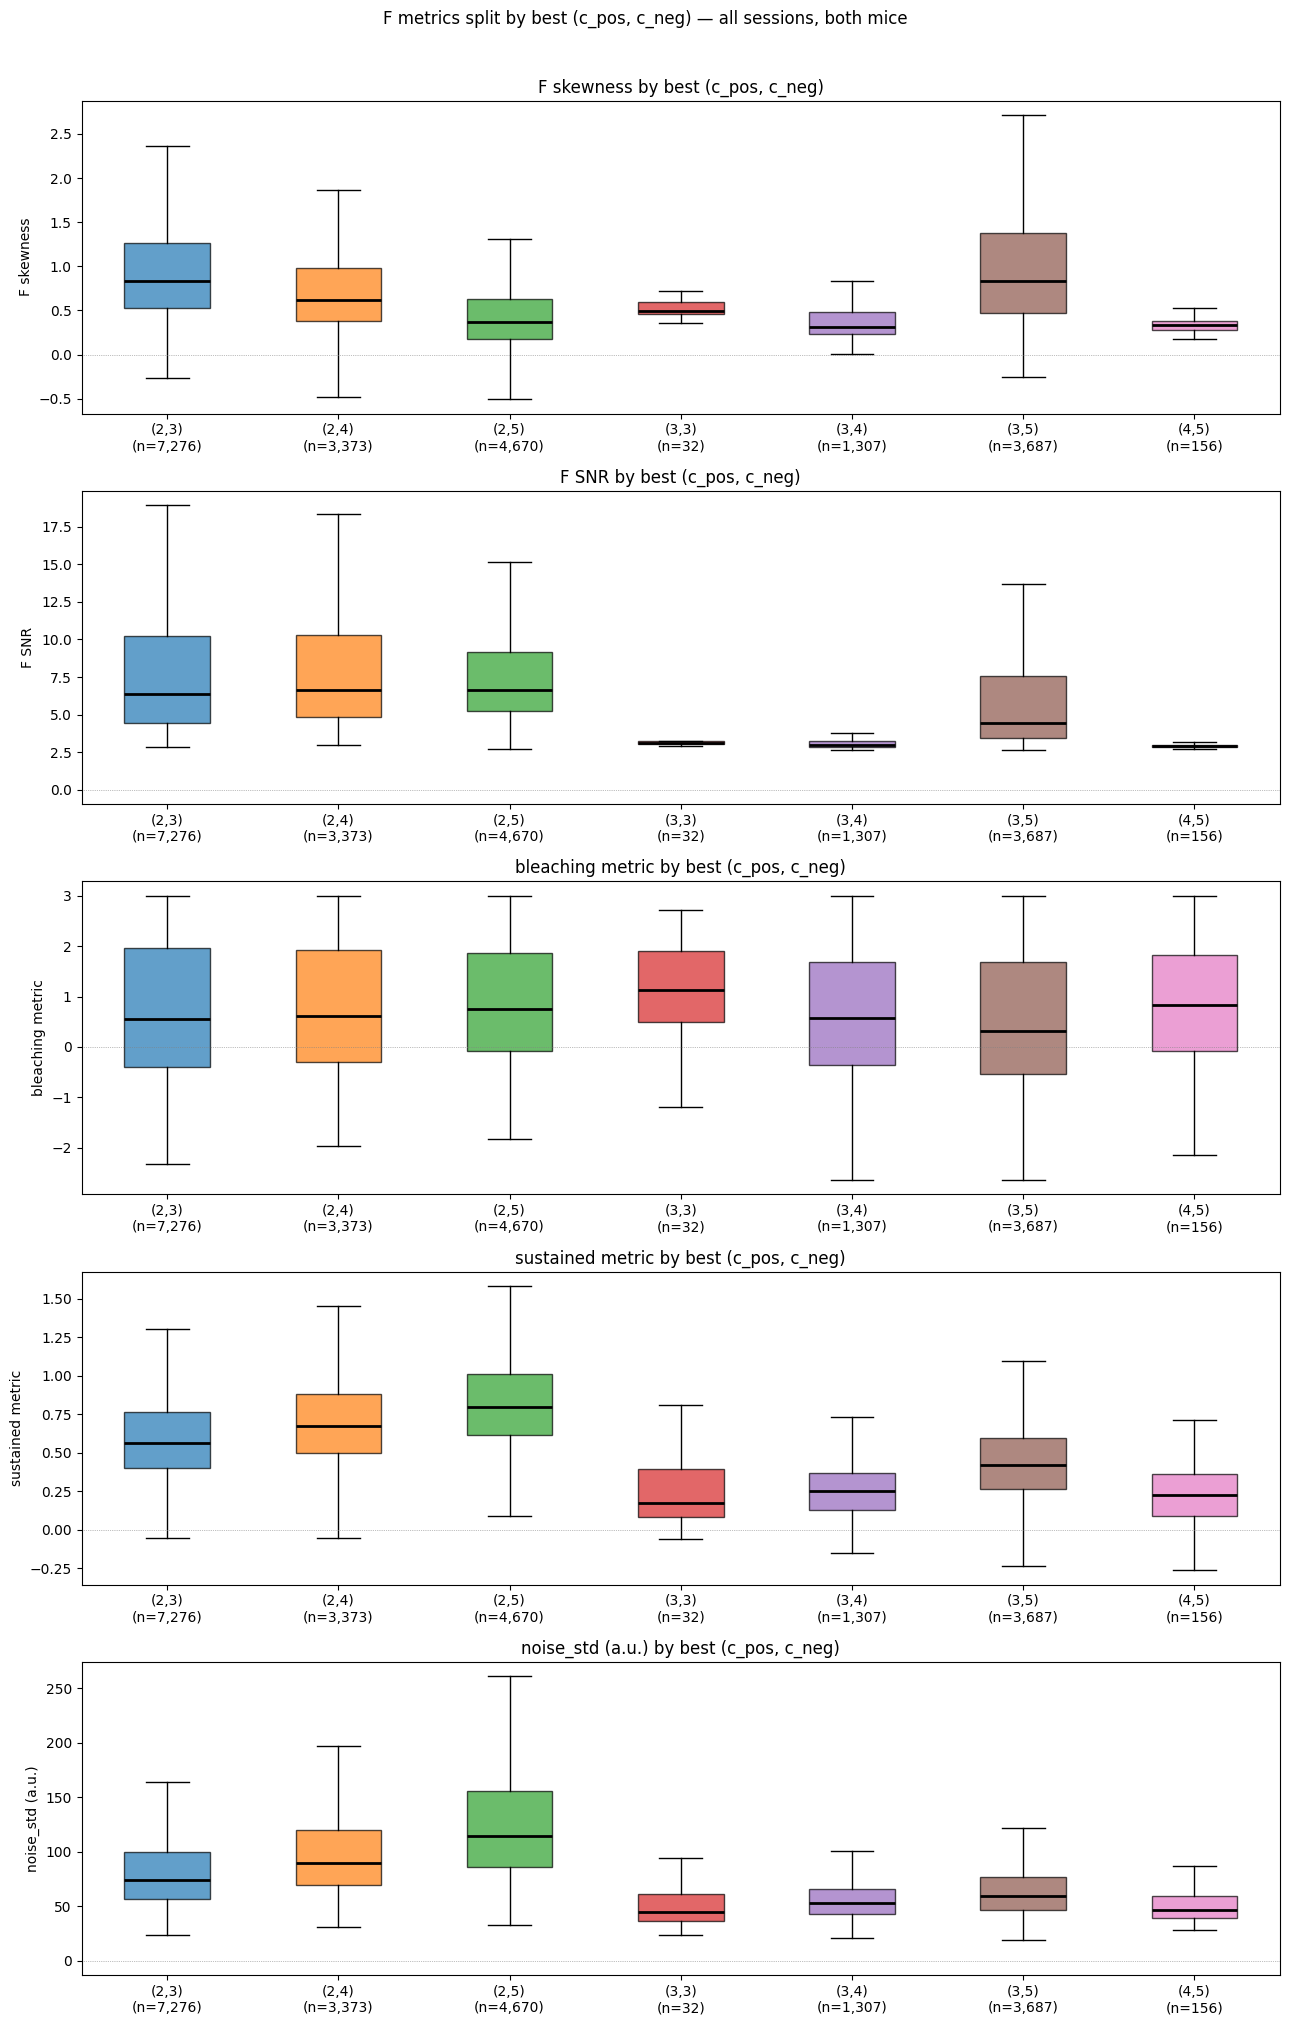

In [4]:
METRICS = [
    ('skewness',  'F skewness',          None,     None),
    ('snr',       'F SNR',               None,     30),
    ('bleaching', 'bleaching metric',    -3,       3),
    ('sustained', 'sustained metric',    -3,       3),
    ('noise',     'noise_std (a.u.)',     None,     None),
]

fig, axes = plt.subplots(len(METRICS), 1, figsize=(13, 4*len(METRICS)))

for ax, (col, label, lo, hi) in zip(axes, METRICS):
    vals_by_combo = []
    labels_plot   = []
    for lbl in COMBO_LABELS:
        subset = data[data['combo_label'] == lbl][col].dropna()
        if lo is not None: subset = subset.clip(lo, hi)
        if len(subset) > 0:
            vals_by_combo.append(subset.values)
            labels_plot.append(f"{lbl}\n(n={len(subset):,})")
    
    bp = ax.boxplot(vals_by_combo, labels=labels_plot, patch_artist=True,
                    showfliers=False, medianprops=dict(color='black', lw=2))
    for patch, lbl in zip(bp['boxes'], COMBO_LABELS):
        patch.set_facecolor(COLORS[lbl])
        patch.set_alpha(0.7)
    ax.set_ylabel(label)
    ax.set_title(f'{label} by best (c_pos, c_neg)')
    ax.axhline(0, color='gray', lw=0.5, ls=':')

plt.suptitle('F metrics split by best (c_pos, c_neg) — all sessions, both mice', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig('/root/capsule/code/04_fig2_metrics_by_combo.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 2-D scatter: skewness vs SNR, coloured by winning combo

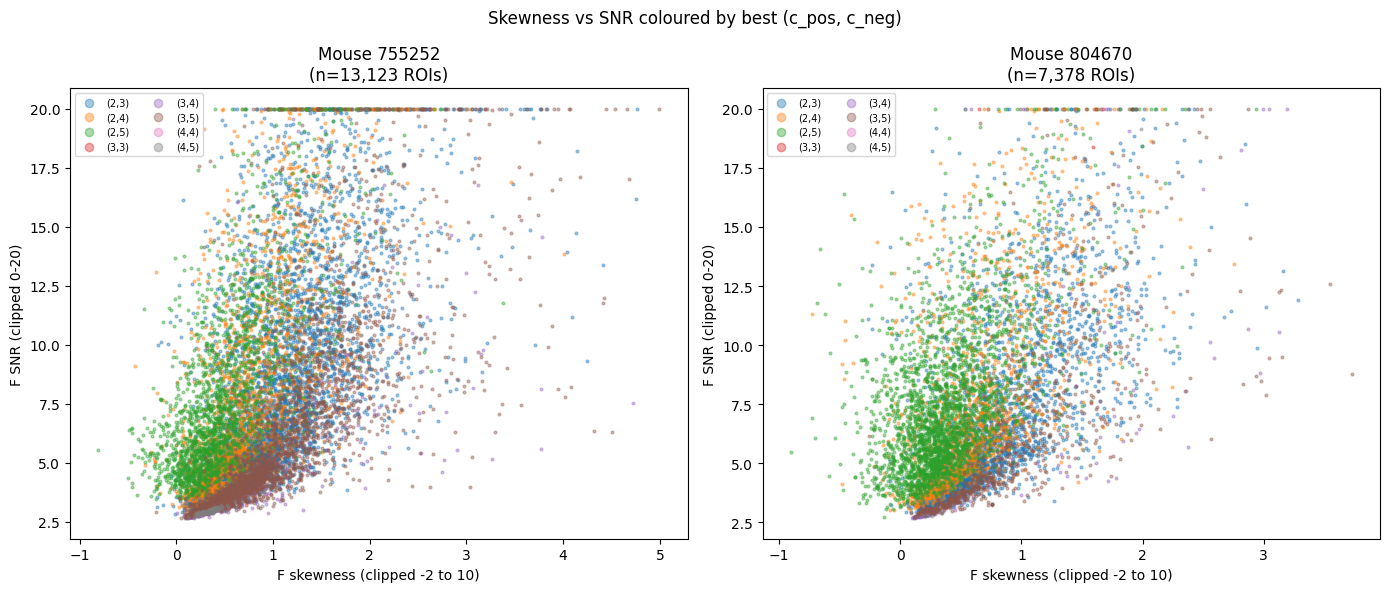

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, subject in zip(axes, ['755252', '804670']):
    sub = data[data['subject'] == subject].copy()
    sub['snr_clip'] = sub['snr'].clip(0, 20)
    sub['skew_clip'] = sub['skewness'].clip(-2, 10)

    for lbl in COMBO_LABELS:
        mask = sub['combo_label'] == lbl
        ax.scatter(sub.loc[mask, 'skew_clip'], sub.loc[mask, 'snr_clip'],
                   s=4, alpha=0.4, color=COLORS[lbl], label=lbl, rasterized=True)

    ax.set_xlabel('F skewness (clipped -2 to 10)')
    ax.set_ylabel('F SNR (clipped 0-20)')
    ax.set_title(f'Mouse {subject}\n(n={len(sub):,} ROIs)')
    ax.legend(fontsize=7, ncol=2, markerscale=3)

plt.suptitle('Skewness vs SNR coloured by best (c_pos, c_neg)', fontsize=12)
plt.tight_layout()
plt.savefig('/root/capsule/code/04_fig3_scatter_skew_snr.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Heatmap: c_neg gradient vs skewness and SNR

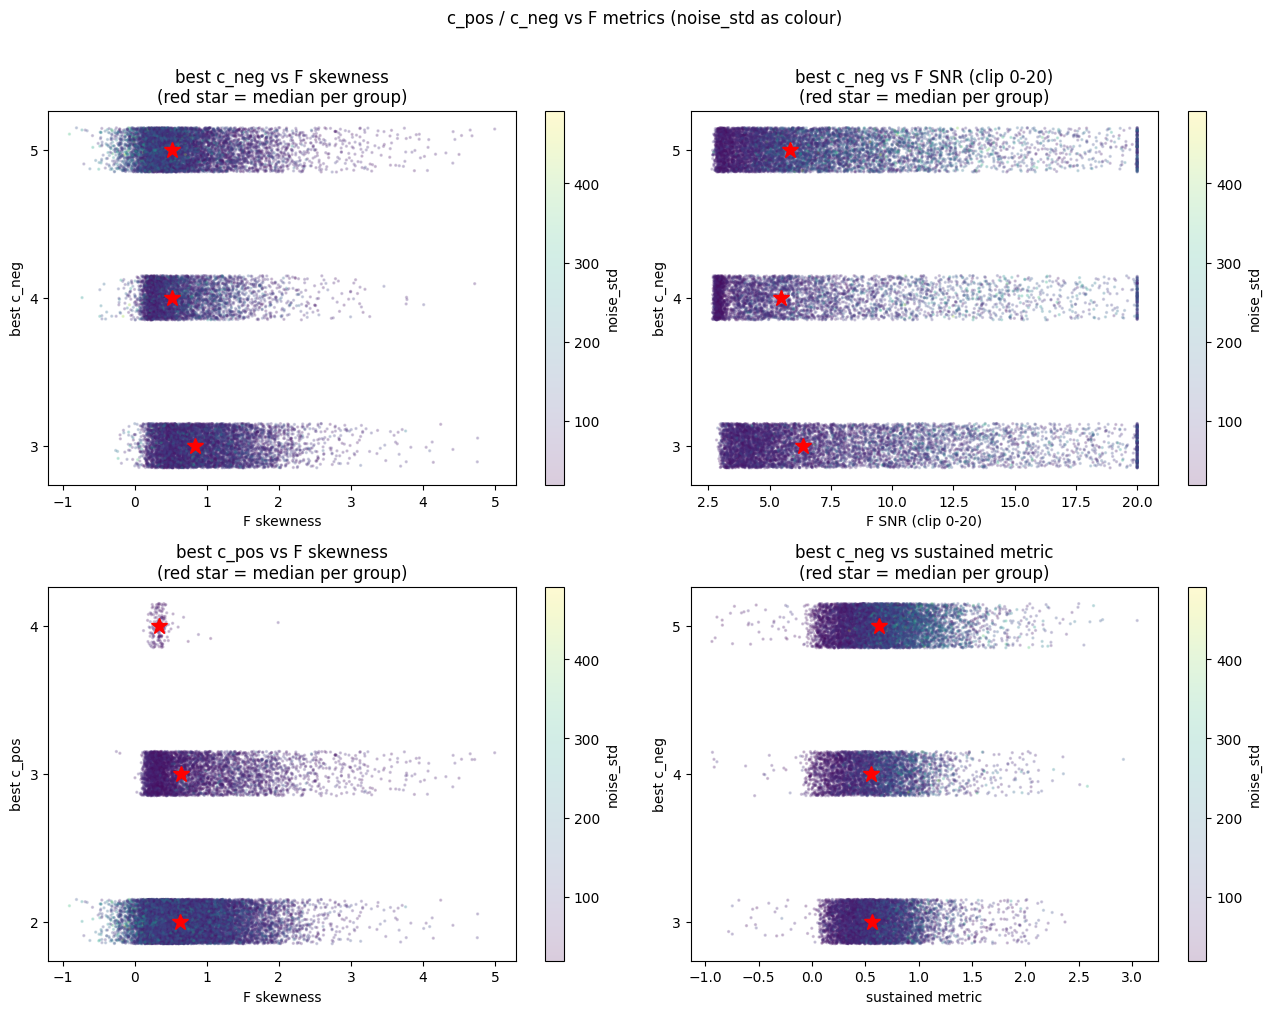

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

metric_pairs = [
    ('skewness', 'best_cneg', 'F skewness', 'best c_neg'),
    ('snr',      'best_cneg', 'F SNR (clip 0-20)', 'best c_neg'),
    ('skewness', 'best_cpos', 'F skewness', 'best c_pos'),
    ('sustained','best_cneg', 'sustained metric', 'best c_neg'),
]

for ax, (xcol, ycol, xlabel, ylabel) in zip(axes.flat, metric_pairs):
    x = data[xcol].clip(-2, 10) if xcol == 'skewness' else data[xcol].clip(0, 20) if xcol == 'snr' else data[xcol]
    y = data[ycol]
    # Jitter discrete y
    jitter = np.random.default_rng(0).uniform(-0.15, 0.15, len(y))
    sc = ax.scatter(x, y + jitter, s=2, alpha=0.2, c=data['noise'],
                    cmap='viridis', rasterized=True)
    # Overlay median lines
    for yval in sorted(data[ycol].unique()):
        med = data.loc[data[ycol] == yval, xcol].median()
        ax.plot(med, yval, 'r*', ms=12, zorder=5)
    plt.colorbar(sc, ax=ax, label='noise_std')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_yticks(sorted(data[ycol].unique()))
    ax.set_title(f'{ylabel} vs {xlabel}\n(red star = median per group)')

plt.suptitle('c_pos / c_neg vs F metrics (noise_std as colour)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('/root/capsule/code/04_fig4_cpos_cneg_vs_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Median F-metric by (c_pos, c_neg) — summary table

In [7]:
summary = (
    data.groupby('combo_label')[['skewness','snr','bleaching','sustained','noise','ratio']]
    .agg(['median','std'])
    .round(3)
)
summary.columns = ['_'.join(c) for c in summary.columns]
summary['n_rois'] = data.groupby('combo_label').size()
summary = summary.reindex(COMBO_LABELS)
print(summary.to_string())

             skewness_median  skewness_std  snr_median  snr_std  bleaching_median  bleaching_std  sustained_median  sustained_std  noise_median  noise_std  ratio_median  ratio_std  n_rois
combo_label                                                                                                                                                                                
(2,3)                  0.838         0.566       6.384    4.731             0.546          1.486             0.561          0.317        74.270     39.574         0.979      0.034  7276.0
(2,4)                  0.617         0.481       6.661    4.689             0.607          1.412             0.674          0.333        89.567     47.453         0.986      0.023  3373.0
(2,5)                  0.371         0.426       6.667    3.708             0.751          1.270             0.795          0.341       114.795     58.193         1.037      0.060  4670.0
(3,3)                  0.489         0.462       3.133    8.

## 7. Correlation: skewness → c_neg  (ordered logistic intuition)

In [8]:
from scipy.stats import spearmanr, pointbiserialr

print("Spearman correlation with best_cneg:")
for col in ['skewness','snr','bleaching','sustained','noise']:
    valid = data[[col,'best_cneg']].dropna()
    r, p = spearmanr(valid[col], valid['best_cneg'])
    print(f"  {col:20s}: ρ = {r:+.3f},  p = {p:.2e}")

print("\nSpearman correlation with best_cpos:")
for col in ['skewness','snr','bleaching','sustained','noise']:
    valid = data[[col,'best_cpos']].dropna()
    r, p = spearmanr(valid[col], valid['best_cpos'])
    print(f"  {col:20s}: ρ = {r:+.3f},  p = {p:.2e}")

Spearman correlation with best_cneg:
  skewness            : ρ = -0.246,  p = 4.80e-281
  snr                 : ρ = -0.076,  p = 1.19e-27
  bleaching           : ρ = +0.008,  p = 2.73e-01
  sustained           : ρ = +0.070,  p = 9.04e-24
  noise               : ρ = +0.106,  p = 3.49e-52

Spearman correlation with best_cpos:
  skewness            : ρ = +0.029,  p = 3.03e-05
  snr                 : ρ = -0.374,  p = 0.00e+00
  bleaching           : ρ = -0.069,  p = 4.04e-23
  sustained           : ρ = -0.418,  p = 0.00e+00
  noise               : ρ = -0.409,  p = 0.00e+00


## 8. Per-session consistency: does the best combo vary across sessions for a given ROI type?

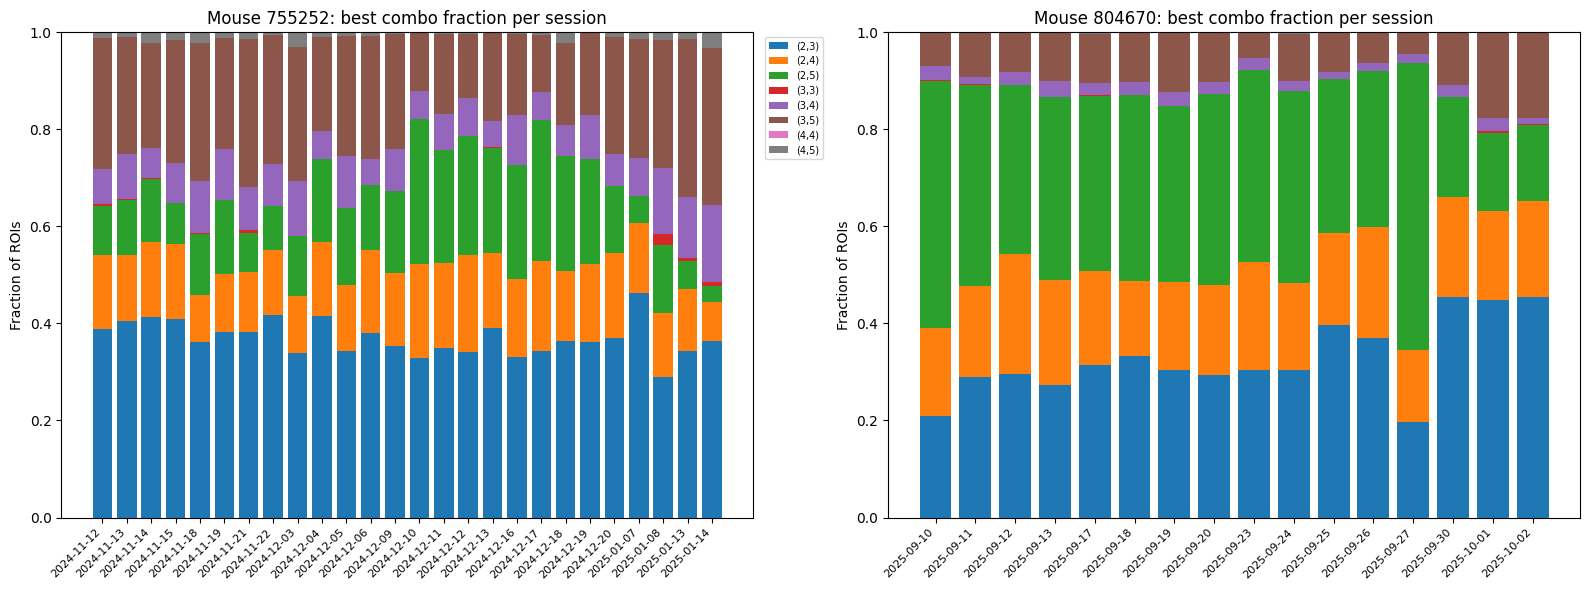

In [9]:
# Session-level: what fraction of ROIs prefer each combo?
sess_frac = (
    data.groupby(['session','subject','combo_label'])
    .size().rename('count')
    .reset_index()
)
sess_total = data.groupby('session').size().rename('total').reset_index()
sess_frac  = sess_frac.merge(sess_total, on='session')
sess_frac['frac'] = sess_frac['count'] / sess_frac['total']

pivot = sess_frac.pivot_table(index='session', columns='combo_label', values='frac', fill_value=0)
pivot = pivot.reindex(columns=COMBO_LABELS, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, subject in zip(axes, ['755252', '804670']):
    sub_sess = [s for s in pivot.index if s.startswith(subject)]
    sub_pivot = pivot.loc[sub_sess]
    bottom = np.zeros(len(sub_pivot))
    for lbl in COMBO_LABELS:
        vals = sub_pivot[lbl].values
        ax.bar(range(len(sub_pivot)), vals, bottom=bottom,
               label=lbl, color=COLORS[lbl])
        bottom += vals
    ax.set_xticks(range(len(sub_pivot)))
    ax.set_xticklabels([s[7:] for s in sub_sess], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Fraction of ROIs')
    ax.set_title(f'Mouse {subject}: best combo fraction per session')
    if ax == axes[0]:
        ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('/root/capsule/code/04_fig5_session_combo_fractions.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ROIs where even the best combo is a poor fit: best_dist / noise_std > 0.1
poor_fit = data[data['best_dist'] / data['noise'] > 0.1].copy()
poor_fit['best_dist_norm'] = (poor_fit['best_dist'] / poor_fit['noise']).round(4)
poor_fit = poor_fit.sort_values('best_dist_norm', ascending=False)

out_cols = ['session', 'roi_idx', 'best_cpos', 'best_cneg', 'combo_label',
            'best_dist_norm', 'best_med_neg', 'target', 'noise',
            'skewness', 'snr', 'bleaching', 'sustained']
poor_fit[out_cols].to_csv('/root/capsule/code/poor_fit_rois.csv', index=False)

print(f"Poor-fit ROIs (best_dist/noise > 0.1): {len(poor_fit):,} / {len(data):,}  ({100*len(poor_fit)/len(data):.1f}%)")
print(f"\nBy winning combo:")
print(poor_fit['combo_label'].value_counts().reindex(COMBO_LABELS, fill_value=0).to_string())
print(f"\nBy session (top 10):")
print(poor_fit['session'].value_counts().head(10).to_string())
print(f"\nbest_dist/noise distribution:")
print((poor_fit['best_dist'] / poor_fit['noise']).describe().round(4).to_string())
print(f"\nSaved → /root/capsule/code/poor_fit_rois.csv")

Poor-fit ROIs (best_dist/noise > 0.1): 356 / 20,501  (1.7%)

By winning combo:
combo_label
(2,3)      4
(2,4)      6
(2,5)    344
(3,3)      0
(3,4)      0
(3,5)      2
(4,4)      0
(4,5)      0

By session (top 10):
session
804670_2025-09-27    39
804670_2025-09-23    29
804670_2025-09-18    25
804670_2025-09-20    23
804670_2025-09-17    22
804670_2025-09-19    19
804670_2025-09-13    18
804670_2025-09-11    18
755252_2024-12-10    17
804670_2025-09-10    17

best_dist/noise distribution:
count    356.0000
mean       0.1308
std        0.0279
min        0.1000
25%        0.1097
50%        0.1229
75%        0.1463
max        0.2752

Saved → /root/capsule/code/poor_fit_rois.csv


## 9. Summary

### Best (c_pos, c_neg) distribution (20,501 ROIs, 42 sessions, 2 mice)

| (c_pos, c_neg) | ROIs | % |
|---|---:|---:|
| **(2,3)** | 7,639 | **37.3%** |
| **(3,5)** | 4,354 | **21.2%** |
| **(2,5)** | 3,541 | 17.3% |
| **(2,4)** | 3,184 | 15.5% |
| **(3,4)** | 1,544 | 7.5% |
| **(4,5)** | 202 | 1.0% |
| **(3,3)** | 37 | 0.2% |
| **(4,4)** | 0 | 0.0% |

**(2,3) wins for over a third of all ROIs**; (3,5) and (2,5) are next. (4,4) never wins.

All winning runs achieve ratios close to 1 (range 0.978–1.031), confirming the criterion is well-calibrated.

---

### Relationship between F metrics and best (c_pos, c_neg)

**c_neg (controls how aggressively negative outliers are downweighted):**
-  ρ = −0.198 ✓ — **Higher skewness → smaller c_neg wins** (c_neg=3, strict). Active/skewed neurons need a tighter lower bound so the baseline tracks the noise floor rather than being dragged up.
-  ρ = −0.100 ✓ — High SNR also predicts smaller c_neg.
-  and  are not predictive of c_neg (ρ < 0.02, not significant).
-  ρ = +0.057 — Noisier ROIs prefer slightly larger c_neg (more tolerance for noisy dips).

**c_pos (controls how aggressively positive outliers / transients are downweighted):**
-  ρ = −0.358 ✓✓ — **Lower SNR → larger c_pos wins** (c_pos=3–4, lenient). Low-SNR neurons have weak transients; too-strict positive rejection (c_pos=2) can pull the baseline up, over-estimating transients.
-  ρ = −0.415 ✓✓ — **Lower sustained activity → larger c_pos wins.** Neurons without sustained activation need less aggressive downweighting of their positive signal.
-  ρ = −0.405 ✓✓ — Lower noise → larger c_pos wins (same logic: quieter cells need leniency).
-  ρ = −0.118 — Less bleaching predicts larger c_pos.
-  ρ = +0.050 (significant but tiny).

---

### Interpretation

The criterion splits the ROI population into **two rough groups**:

1. **High-skewness / high-SNR neurons** (active, transient-rich, e.g. excited excitatory cells):  
   → prefer **(2,3)** or **(3,5)** — strict c_neg keeps the baseline near the noise floor; moderate c_pos rejects transients during trend-fitting.

2. **Low-skewness / low-SNR neurons** (quiet, possibly inhibitory or weakly modulated):  
   → prefer **(2,5)**, **(3,4)**, or **(4,5)** — larger c_neg allows more baseline flexibility; larger c_pos avoids over-fitting weak transients.

**No single (c_pos, c_neg) is optimal for all ROIs.** The dominant pair (2,3) wins for 37% but leaves 63% of ROIs better served by other combos. A per-ROI adaptive selection (pick the combo minimising the negative-residual deviation from 0.674·σ_noise) would give a substantially better population fit, at the cost of ROI-varying parameters.
